In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import yfinance as yf
import seaborn as sns
import time
import re
import os
import matplotlib.pyplot as plt
from yfinance.exceptions import YFRateLimitError
from yfinance import shared
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Display all columns
pd.set_option('display.max_columns', None)

# Load experiment dataset, skipping any irrelevant rows if necessary
exp_data = pd.read_excel("data_raw_all_sessions.xlsx", skiprows=1)

# Extract only the date part from the actual 'STARTED' column using regex
exp_data['Date'] = exp_data['Zeitpunkt zu dem das Interview begonnen hat'].astype(str).str.extract(r'(\d{2}-\d{2}-\d{4})')[0]

# Convert 'Date' to datetime format
exp_data['Date'] = pd.to_datetime(exp_data['Date'], format='%d-%m-%Y').dt.date

# Drop the original 'STARTED' column
exp_data.drop(columns=['Zeitpunkt zu dem das Interview begonnen hat'], inplace=True)

In [3]:
# Full Dictionary for Translating Key German Headers
column_translation = {
    # Personal & Survey Data
    "Interview-Nummer (fortlaufend)": "Interview Number",
    "Seriennummer (sofern verwendet)": "Serial Number",
    "Referenz (sofern im Link angegeben)": "Reference",
    "Fragebogen, der im Interview verwendet wurde": "Survey Used",
    "Interview-Modus": "Interview Mode",
    "Seat: Sitzplatznummer": "Seat Number",
    
    # Financial Behavior
    "tradingfrequency": "Trading Frequency",
    "delegation": "Delegation",
    "trustadvisor: [Keine Beschreibung] 01": "Trust in Advisor",
    "patience: [Keine Beschreibung] 01": "Patience",
    "riskattitude: [Keine Beschreibung] 01": "Risk Attitude",
    "fear: [Keine Beschreibung] 01": "Fear Level",
    "investambiguity_ratio:  ... Euro": "Investment Ambiguity Ratio",
    "guessballs:  ... Prozent": "Guessing Percentage",
    "investrisk_ratio:  ... Euro": "Investment Risk Ratio",
    "optimism: Insgesamt erwarte ich, dass mir mehr gute als schlechte Dinge passieren.": "Optimism",
    "jobsecurity: Es ist wahrscheinlich, dass ich nach dem Studium einen Job finde.": "Job Security",
    "bullish: [Keine Beschreibung] 01": "Bullish Sentiment",

    # Financial Literacy
    "literacy1": "Financial Literacy 1",
    "literacy2": "Financial Literacy 2",
    "literacy3": "Financial Literacy 3",
    "literacy4": "Financial Literacy 4",
    "confidenceliteracy": "Confidence in Financial Literacy",

    # Demographics
    "age: Ich bin \xa0 ... Jahre": "Age",
    "gender": "Gender",
    "nationality: Ich komme aus": "Nationality",
    "study program: [01]": "Study Program",
    "income": "Income",
    "comments: [01]": "Comments",

    # Questions
    "Frage1: [01]": "Question 1",
    "Frage2: [01]": "Question 2",
    "Frage3: [01]": "Question 3",
    "Frage4: [01]": "Question 4",
    "Frage5: [01]": "Question 5",
    "IV01: scenario": "Investment Scenario",
    "goodmood": "Good Mood Level",

    # Time Spent on Survey Pages
    "Verweildauer Seite 1": "Time Spent Page 1",
    "Verweildauer Seite 2": "Time Spent Page 2",
    "Verweildauer Seite 3": "Time Spent Page 3",
    "Verweildauer Seite 4": "Time Spent Page 4",
    "Verweildauer Seite 5": "Time Spent Page 5",
    "Verweildauer Seite 6": "Time Spent Page 6",
    "Verweildauer Seite 7": "Time Spent Page 7",
    "Verweildauer Seite 8": "Time Spent Page 8",
    "Verweildauer Seite 9": "Time Spent Page 9",
    "Verweildauer Seite 10": "Time Spent Page 10",
    "Verweildauer Seite 11": "Time Spent Page 11",
    "Verweildauer Seite 12": "Time Spent Page 12",
    "Verweildauer Seite 13": "Time Spent Page 13",
    "Verweildauer Seite 14": "Time Spent Page 14",
    "Verweildauer gesamt (ohne Ausreißer)": "Total Time Spent (Without Outliers)",

    # Survey Metadata
    "Versandzeitpunkt der Einladungsmail (nur für nicht-anonyme Adressaten)": "Invitation Email Sent Time",
    "Zeitpunkt als der Datensatz das letzte mal geändert wurde": "Last Data Change Time",
    "Wurde die Befragung abgeschlossen (letzte Seite erreicht)?": "Survey Completed",
    "Hat der Teilnehmer den Fragebogen nur angesehen, ohne die Pflichtfragen zu beantworten?": "Only Viewed Survey",
    "Seite, die der Teilnehmer zuletzt bearbeitet hat": "Last Page Completed",
    "Letzte Seite, die im Fragebogen bearbeitet wurde": "Final Page Completed",

    # Missing Data and Penalties
    "Anteil fehlender Antworten in Prozent": "Missing Answers Percentage",
    "Anteil fehlender Antworten (gewichtet nach Relevanz)": "Weighted Missing Answers",
    "Maluspunkte für fehlende Antworten": "Penalty for Missing Answers",
    "Maluspunkte für schnelles Ausfüllen": "Penalty for Fast Completion",
    "Maluspunkte gesamt": "Total Penalty",
    
    # Market Data Columns
    "Date": "Date",
    "Open": "Market Open Price",
    "High": "Market High Price",
    "Low": "Market Low Price",
    "Close": "Market Close Price",
    "Volume": "Market Trading Volume",
    "Dividends": "Market Dividends",
    "Stock Splits": "Market Stock Splits",
    "Daily_Return": "Market Daily Return",
    "Volatility": "Market Volatility",
    "MA_5": "5-Day Moving Average",
    "MA_10": "10-Day Moving Average"
}

# Apply translations
exp_data.rename(columns=column_translation, inplace=True)

# Strip any spaces from column names
exp_data.columns = exp_data.columns.str.strip()

# Verify translation
print(exp_data.columns)


Index(['Interview Number', 'Serial Number', 'Reference', 'Survey Used',
       'Interview Mode', 'Seat Number', 'Trading Frequency', 'Delegation',
       'Trust in Advisor', 'Patience', 'Risk Attitude', 'Question 1',
       'Question 2', 'Question 3', 'Question 4', 'Question 5',
       'Investment Scenario', 'Good Mood Level', 'Fear Level',
       'Investment Ambiguity Ratio', 'Guessing Percentage',
       'Investment Risk Ratio', 'Optimism', 'Job Security',
       'Bullish Sentiment', 'Financial Literacy 1', 'Financial Literacy 2',
       'Financial Literacy 3', 'Financial Literacy 4',
       'Confidence in Financial Literacy', 'Age', 'Gender', 'Nationality',
       'Study Program', 'Income', 'Comments', 'Time Spent Page 1',
       'Time Spent Page 2', 'Time Spent Page 3', 'Time Spent Page 4',
       'Time Spent Page 5', 'Time Spent Page 6', 'Time Spent Page 7',
       'Time Spent Page 8', 'Time Spent Page 9', 'Time Spent Page 10',
       'Time Spent Page 11', 'Time Spent Page 12', 'T

In [4]:
# Print all column names exactly as they appear
print(list(exp_data.columns))


['Interview Number', 'Serial Number', 'Reference', 'Survey Used', 'Interview Mode', 'Seat Number', 'Trading Frequency', 'Delegation', 'Trust in Advisor', 'Patience', 'Risk Attitude', 'Question 1', 'Question 2', 'Question 3', 'Question 4', 'Question 5', 'Investment Scenario', 'Good Mood Level', 'Fear Level', 'Investment Ambiguity Ratio', 'Guessing Percentage', 'Investment Risk Ratio', 'Optimism', 'Job Security', 'Bullish Sentiment', 'Financial Literacy 1', 'Financial Literacy 2', 'Financial Literacy 3', 'Financial Literacy 4', 'Confidence in Financial Literacy', 'Age', 'Gender', 'Nationality', 'Study Program', 'Income', 'Comments', 'Time Spent Page 1', 'Time Spent Page 2', 'Time Spent Page 3', 'Time Spent Page 4', 'Time Spent Page 5', 'Time Spent Page 6', 'Time Spent Page 7', 'Time Spent Page 8', 'Time Spent Page 9', 'Time Spent Page 10', 'Time Spent Page 11', 'Time Spent Page 12', 'Time Spent Page 13', 'Time Spent Page 14', 'Total Time Spent (Without Outliers)', 'Invitation Email Sent 

In [5]:
# Loading DAX market data from Yahoo Finance
# 1) Define your tickers and date-range once
tickers    = ["^GDAXI", "^GSPC"]
start_date = "2015-05-22"
end_date   = "2017-05-04"

# 2) A helper that retries on rate-limit (HTTP 429)
def download_with_retry(ticker, **kwargs):
    for attempt in range(5):
        try:
            return yf.download(ticker, **kwargs)
        except Exception as e:
            if "Too Many Requests" in str(e):
                wait = 2 ** attempt
                print(f"[{ticker}] Rate-limit hit; retrying in {wait}s…")
                time.sleep(wait)
            else:
                raise
    raise RuntimeError(f"Failed to download {ticker} after retries")

# 3) Loop over tickers, passing actual strings (or your date vars)
for ticker in tickers:
    df = download_with_retry(
        ticker,
        start=start_date,
        end=end_date,
        threads=False
    )
    df = df.reset_index()
    df["Date"] = df["Date"].dt.date
    print(f"\n=== {ticker} ===")
    print(df.head())
    time.sleep(1)  # sleep 1 sec between downloads

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed



=== ^GDAXI ===
Price         Date         Close          High           Low          Open  \
Ticker                    ^GDAXI        ^GDAXI        ^GDAXI        ^GDAXI   
0       2015-05-22  11815.009766  11881.809570  11792.309570  11881.490234   
1       2015-05-26  11625.129883  11920.309570  11586.349609  11841.480469   
2       2015-05-27  11771.129883  11790.349609  11595.120117  11647.040039   
3       2015-05-28  11677.570312  11773.790039  11605.990234  11716.080078   
4       2015-05-29  11413.820312  11704.389648  11403.820312  11685.660156   

Price      Volume  
Ticker     ^GDAXI  
0        64150300  
1        96666700  
2       100896100  
3        84031300  
4       124443600  


[*********************100%***********************]  1 of 1 completed



=== ^GSPC ===
Price         Date        Close         High          Low         Open  \
Ticker                    ^GSPC        ^GSPC        ^GSPC        ^GSPC   
0       2015-05-22  2126.060059  2132.149902  2126.060059  2130.360107   
1       2015-05-26  2104.199951  2125.340088  2099.179932  2125.340088   
2       2015-05-27  2123.479980  2126.219971  2105.129883  2105.129883   
3       2015-05-28  2120.790039  2122.270020  2112.860107  2122.270020   
4       2015-05-29  2107.389893  2120.659912  2104.889893  2120.659912   

Price       Volume  
Ticker       ^GSPC  
0       2571860000  
1       3342130000  
2       3127960000  
3       2980350000  
4       3927390000  


In [6]:
# Load DAX market data from Yahoo Finance
dax = yf.Ticker("^GDAXI")
# Fetch historical DAX data
start_date = "2015-05-22"
end_date = "2017-05-04"
dax_data = dax.history(start=start_date, end=end_date)

# Reset index to convert date index into a column
dax_data = dax_data.reset_index()

# Display the first few rows
print(dax_data.head())


# # Convert DAX date column to date format
# dax_data['Date'] = dax_data['Date'].dt.date

                       Date          Open          High           Low  \
0 2015-05-22 00:00:00+02:00  11881.490234  11881.809570  11792.309570   
1 2015-05-26 00:00:00+02:00  11841.480469  11920.309570  11586.349609   
2 2015-05-27 00:00:00+02:00  11647.040039  11790.349609  11595.120117   
3 2015-05-28 00:00:00+02:00  11716.080078  11773.790039  11605.990234   
4 2015-05-29 00:00:00+02:00  11685.660156  11704.389648  11403.820312   

          Close     Volume  Dividends  Stock Splits  
0  11815.009766   64150300        0.0           0.0  
1  11625.129883   96666700        0.0           0.0  
2  11771.129883  100896100        0.0           0.0  
3  11677.570312   84031300        0.0           0.0  
4  11413.820312  124443600        0.0           0.0  


In [7]:
print(dax_data.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits'],
      dtype='object')


In [8]:
## FEATURE ENGINEERING
# Calculate Daily Returns
dax_data["Daily_Return"] = (dax_data["Close"] - dax_data["Open"]) / dax_data["Open"]

# Calculate Volatility
dax_data["Volatility"] = dax_data["High"] - dax_data["Low"]

# Compute Moving Averages
dax_data["MA_5"] = dax_data["Close"].rolling(window=5).mean()  # 5-day moving average
dax_data["MA_10"] = dax_data["Close"].rolling(window=10).mean()  # 10-day moving average

# Display the first few rows to verify
print(dax_data.head())

                       Date          Open          High           Low  \
0 2015-05-22 00:00:00+02:00  11881.490234  11881.809570  11792.309570   
1 2015-05-26 00:00:00+02:00  11841.480469  11920.309570  11586.349609   
2 2015-05-27 00:00:00+02:00  11647.040039  11790.349609  11595.120117   
3 2015-05-28 00:00:00+02:00  11716.080078  11773.790039  11605.990234   
4 2015-05-29 00:00:00+02:00  11685.660156  11704.389648  11403.820312   

          Close     Volume  Dividends  Stock Splits  Daily_Return  Volatility  \
0  11815.009766   64150300        0.0           0.0     -0.005595   89.500000   
1  11625.129883   96666700        0.0           0.0     -0.018271  333.959961   
2  11771.129883  100896100        0.0           0.0      0.010654  195.229492   
3  11677.570312   84031300        0.0           0.0     -0.003287  167.799805   
4  11413.820312  124443600        0.0           0.0     -0.023263  300.569336   

           MA_5  MA_10  
0           NaN    NaN  
1           NaN    NaN  

We're doing feature engineering because it helps improve the predictive power of your machine learning model. 
Here’s why each feature is important:

1. Daily Returns (Close - Open) / Open
Why?

Measures market momentum—how much the DAX price changes in a day.
Helps capture short-term trends that might influence trading decisions.
Investors might be more confident (or fearful) if returns are consistently positive/negative.

How it helps in ML?

Could be a useful feature for predicting investment behavior in your dataset.
If traders see positive returns, they might be more willing to invest (or vice versa).

2. Volatility (High - Low)
Why?

Captures market uncertainty and fluctuations.
High volatility days could indicate market stress (which may affect investor behavior).

How it helps in ML?

Investors might avoid trading on highly volatile days due to risk.
Some investors might prefer volatility for high-reward opportunities.
Helps ML models differentiate between calm and turbulent market conditions.

3. Moving Averages (5-day & 10-day of Close price)
Why?

Used in technical analysis to understand market trends.
5-day MA captures short-term trends, while 10-day MA smooths them out.

How it helps in ML?

Investors often follow moving averages to make decisions.
A rising moving average might signal positive sentiment, while a declining one could indicate fear or caution.
Helps the model identify momentum shifts.

Bottom Line
By adding these features, we’re giving our ML model more useful information about market conditions. 
This should improve prediction accuracy for investment decisions.

In [9]:
# Convert 'Date' in DAX data to match the format of 'exp_data' Date column
dax_data["Date"] = pd.to_datetime(dax_data["Date"]).dt.date

In [10]:
# Convert "Last Data Change Time" to datetime and extract only the date
exp_data["Date"] = pd.to_datetime(exp_data["Last Data Change Time"]).dt.date

# Verify conversion
print(exp_data["Date"].head(10))


0    2015-05-22
1    2015-05-22
2    2015-05-22
3    2015-05-22
4    2015-05-22
5    2015-05-22
6    2015-05-22
7    2015-05-22
8    2015-05-22
9    2015-05-22
Name: Date, dtype: object


In [11]:
## MERGING THE TWO DATA SETS.

# Convert both 'Date' columns to string format
exp_data["Date"] = exp_data["Date"].astype(str)
dax_data["Date"] = dax_data["Date"].astype(str)

# Merge the datasets on 'Date' using a left join (keeping all exp_data records)
merged_data = pd.merge(exp_data, dax_data, on="Date", how="left")

# Display the first few rows to verify the merge
print(merged_data.head())

   Interview Number  Serial Number  Reference Survey Used Interview Mode  \
0               119            NaN        NaN        base      interview   
1               121            NaN        NaN        base      interview   
2               122            NaN        NaN        base      interview   
3               123            NaN        NaN        base      interview   
4               124            NaN        NaN        base      interview   

   Seat Number  Trading Frequency  Delegation  Trust in Advisor  Patience  \
0            9                  1           2                 3         8   
1            1                  3           2                 4         5   
2            6                  2           1                 4         8   
3            7                  1           1                 3         6   
4            2                  1           2                 5         8   

   Risk Attitude                                         Question 1  \
0        

In [12]:
# # Check for missing values in the entire dataset
# print(merged_data.isnull().sum())

# Check if there are missing values in the Date column
print(merged_data["Date"].isnull().sum())


0


In [13]:
print(list(merged_data.columns))

['Interview Number', 'Serial Number', 'Reference', 'Survey Used', 'Interview Mode', 'Seat Number', 'Trading Frequency', 'Delegation', 'Trust in Advisor', 'Patience', 'Risk Attitude', 'Question 1', 'Question 2', 'Question 3', 'Question 4', 'Question 5', 'Investment Scenario', 'Good Mood Level', 'Fear Level', 'Investment Ambiguity Ratio', 'Guessing Percentage', 'Investment Risk Ratio', 'Optimism', 'Job Security', 'Bullish Sentiment', 'Financial Literacy 1', 'Financial Literacy 2', 'Financial Literacy 3', 'Financial Literacy 4', 'Confidence in Financial Literacy', 'Age', 'Gender', 'Nationality', 'Study Program', 'Income', 'Comments', 'Time Spent Page 1', 'Time Spent Page 2', 'Time Spent Page 3', 'Time Spent Page 4', 'Time Spent Page 5', 'Time Spent Page 6', 'Time Spent Page 7', 'Time Spent Page 8', 'Time Spent Page 9', 'Time Spent Page 10', 'Time Spent Page 11', 'Time Spent Page 12', 'Time Spent Page 13', 'Time Spent Page 14', 'Total Time Spent (Without Outliers)', 'Invitation Email Sent 

In [14]:
## VISUALISATIONS

# Set plot style
plt.style.use("ggplot")

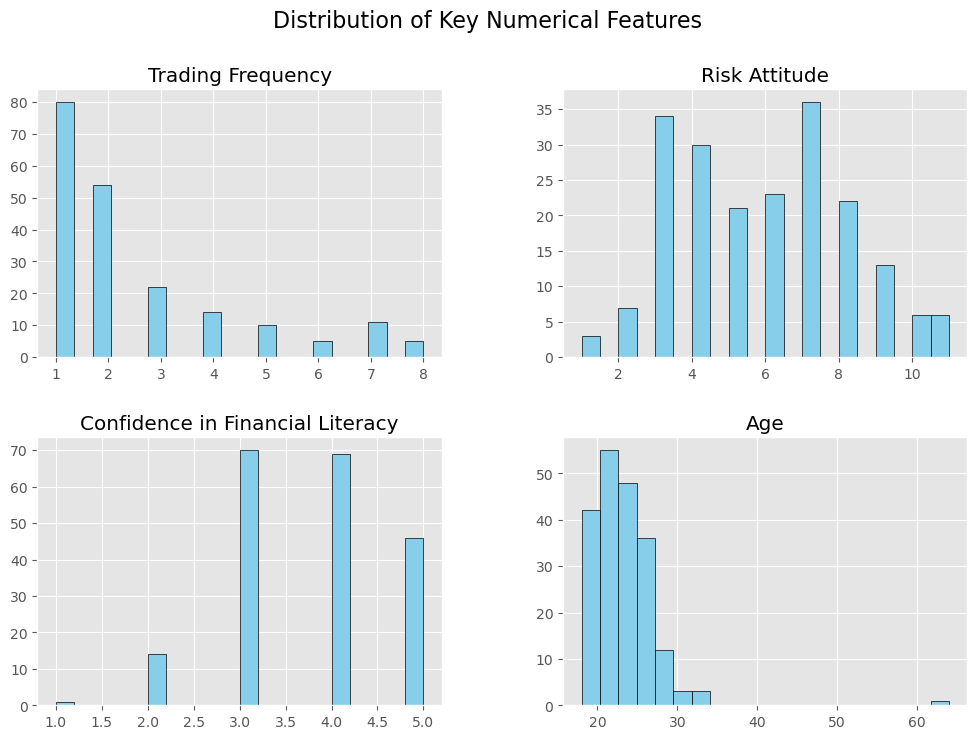

In [15]:
#1. **Distribution of Key Numerical Variables**
numeric_cols = [
    "Trading Frequency", "Risk Attitude", "Investment Ambiguity Ratio", 
    "Investment Risk Ratio", "Confidence in Financial Literacy", "Age"
]

exp_data[numeric_cols].hist(figsize=(12, 8), bins=20, color="skyblue", edgecolor="black")
plt.suptitle("Distribution of Key Numerical Features", fontsize=16)
plt.show()


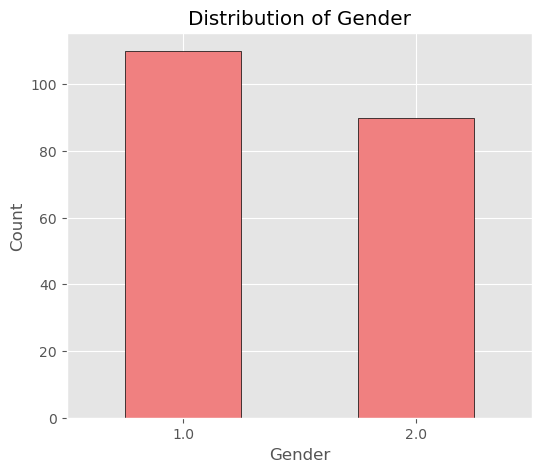

In [16]:
#2. **Bar Chart for Categorical Variable: Gender**
plt.figure(figsize=(6, 5))
exp_data["Gender"].value_counts().plot(kind="bar", color="lightcoral", edgecolor="black")
plt.title("Distribution of Gender")
plt.ylabel("Count")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.show()


1.0 - (should be) male
2.0 - (should be) female

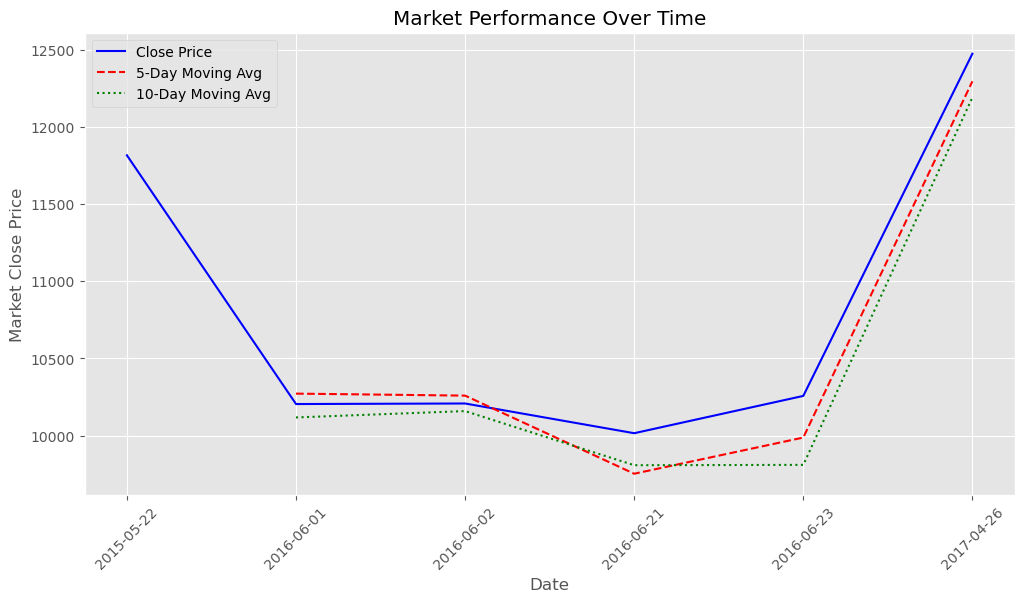

In [17]:
## Visualizing Market Trends Over Time
# Ensure 'Date' is sorted
merged_data = merged_data.sort_values(by="Date")

# Plot Market Close Price and Moving Averages
plt.figure(figsize=(12, 6))
plt.plot(merged_data["Date"], merged_data["Close"], label="Close Price", color="blue")
plt.plot(merged_data["Date"], merged_data["MA_5"], label="5-Day Moving Avg", linestyle="dashed", color="red")
plt.plot(merged_data["Date"], merged_data["MA_10"], label="10-Day Moving Avg", linestyle="dotted", color="green")

plt.xlabel("Date")
plt.ylabel("Market Close Price")
plt.title("Market Performance Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.show()

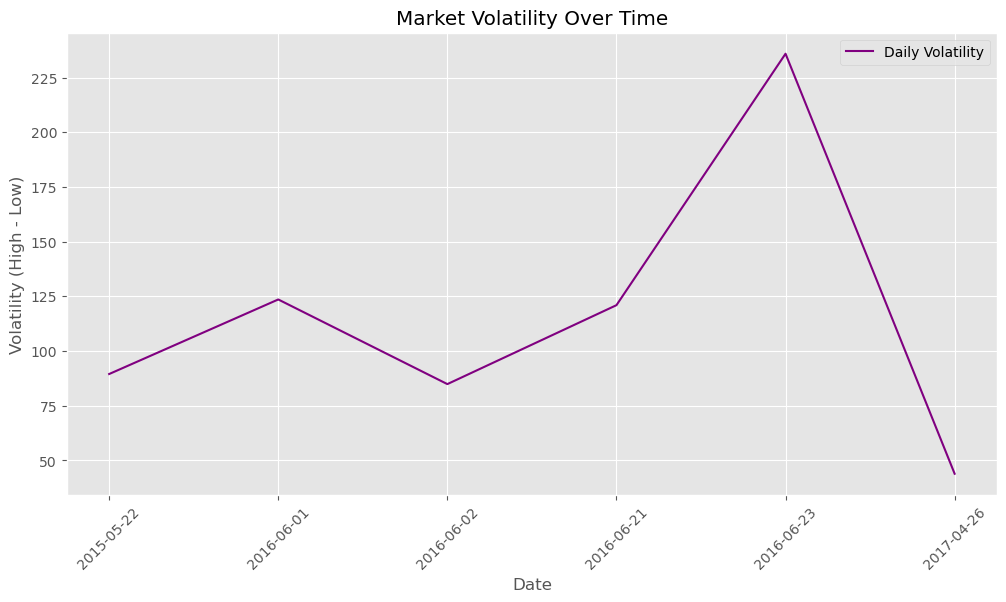

In [18]:
## Plotting Market Volatility
plt.figure(figsize=(12, 6))
plt.plot(merged_data["Date"], merged_data["Volatility"], label="Daily Volatility", color="purple")

plt.xlabel("Date")
plt.ylabel("Volatility (High - Low)")
plt.title("Market Volatility Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.show()

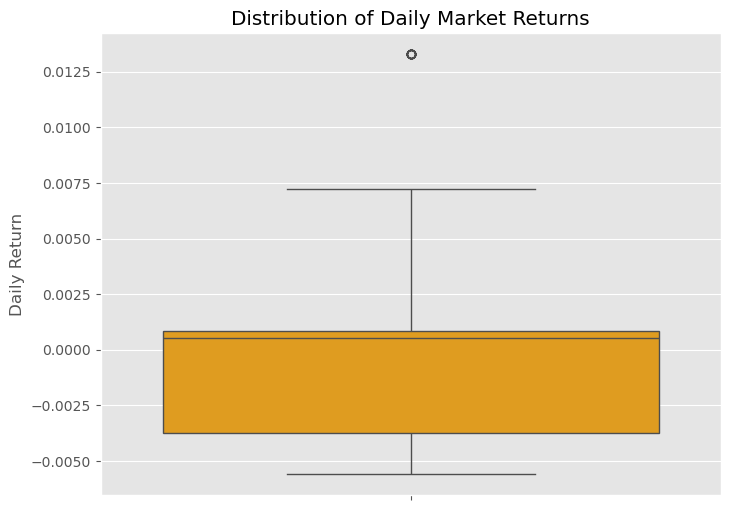

In [19]:
## Boxplot of Daily Returns
plt.figure(figsize=(8, 6))
sns.boxplot(y=merged_data["Daily_Return"], color="orange")
plt.title("Distribution of Daily Market Returns")
plt.ylabel("Daily Return")
plt.show()

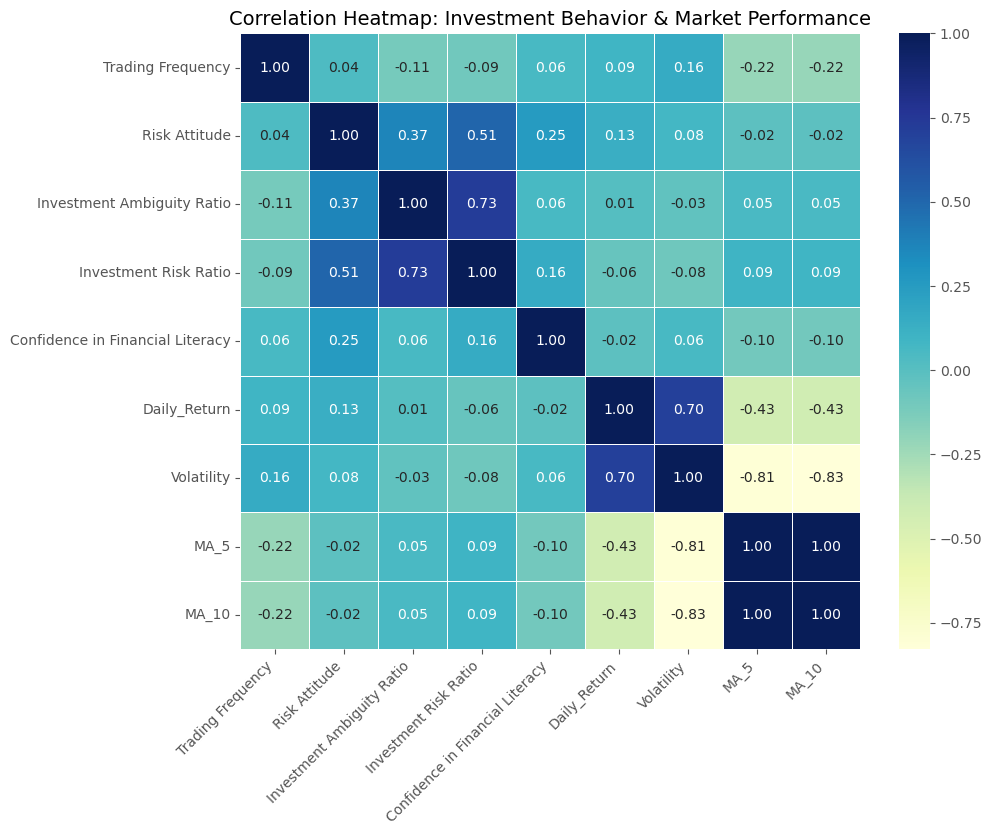

In [20]:
#4. **Correlation Heatmap**

# Select only relevant numerical columns, ignoring datetime and categorical ones
correlation_features = [
    "Trading Frequency", "Risk Attitude", "Investment Ambiguity Ratio",
    "Investment Risk Ratio", "Confidence in Financial Literacy",
    "Daily_Return", "Volatility", "MA_5", "MA_10"
]

# Ensure selected columns exist in the dataset
available_features = [col for col in correlation_features if col in merged_data.columns]

# Convert selected columns to numeric (force conversion to avoid TypeErrors)
numeric_data = merged_data[available_features].apply(pd.to_numeric, errors="coerce")

# Drop any rows that still contain NaN (optional, depending on the dataset)
numeric_data = numeric_data.dropna()

# Compute correlation matrix
corr_matrix = numeric_data.corr()

# Set up the figure size
plt.figure(figsize=(10, 8))

# Create heatmap with adjusted aesthetics
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5, annot_kws={"size": 10})

# Improve label readability
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

# Title
plt.title("Correlation Heatmap: Investment Behavior & Market Performance", fontsize=14)

plt.show()

## Key Insights from the Correlation Heatmap
1) Strong Positive Correlations:

- Investment Ambiguity Ratio and Investment Risk Ratio (0.73)
    - Higher investment ambiguity is linked to higher risk-taking.
- Risk Attitude and Investment Risk Ratio (0.51)
    - More risk-seeking individuals tend to invest more in risky assets.
- Daily Return and Volatility (0.70)
    - Higher market fluctuations are associated with larger daily return swings.

2) Strong Negative Correlations:

- Volatility and 5-Day/10-Day Moving Averages (-0.81, -0.83)
    - Increased volatility disrupts short-term market trends.
- Daily Return and Moving Averages (-0.43)
    - Large fluctuations in daily returns impact short-term trend indicators.

3) Weak or No Correlation with Trading Frequency:

- Trading Frequency and Risk Attitude (0.04)
    - Trading frequently does not necessarily indicate a higher risk appetite.
- Trading Frequency and Market Volatility (0.16)
    - Volatility does not significantly influence how often someone trades.

4) Financial Literacy Shows Weak Influence:

- Financial Literacy and Investment Risk Ratio (0.16)
    - Some link between financial knowledge and risk-taking, but not strong.
- Financial Literacy and Daily Return (-0.02)
    - Market returns do not significantly affect financial confidence.

<!-- Implications for the Research Question
Risk attitude appears to be the strongest factor in investment behavior.
Market conditions, such as volatility and returns, impact investments but indirectly.
Confidence in financial literacy has only a minor effect on risk-taking behavior.
Trading frequency does not show strong relationships with either risk attitude or market performance. -->

In [21]:
# Check the number of samples (rows) and features (columns)
num_samples, num_features = merged_data.shape

# Print the result
print(f"Number of Samples: {num_samples}")
print(f"Number of Features: {num_features}")


Number of Samples: 201
Number of Features: 74


In [22]:
# Count non-null values in a key DAX column (e.g., "Close" for market prices)
num_dax_samples = merged_data["Close"].notna().sum()

# Print result
print(f"Total DAX Samples: {num_dax_samples}")


Total DAX Samples: 191


In [23]:
print("Available columns in correlation matrix:\n", corr_matrix.columns)


Available columns in correlation matrix:
 Index(['Trading Frequency', 'Risk Attitude', 'Investment Ambiguity Ratio',
       'Investment Risk Ratio', 'Confidence in Financial Literacy',
       'Daily_Return', 'Volatility', 'MA_5', 'MA_10'],
      dtype='object')


Top 10 Predictors of Investment Risk Ratio:

Investment Ambiguity Ratio          0.725583
Risk Attitude                       0.508406
Confidence in Financial Literacy    0.155093
MA_5                                0.093353
MA_10                               0.090314
Trading Frequency                   0.090187
Volatility                          0.079266
Daily_Return                        0.055747
Name: Investment Risk Ratio, dtype: float64


C:\Users\amrit\AppData\Local\Temp\ipykernel_5340\1948791357.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.index, y=top_features.values, palette="coolwarm")


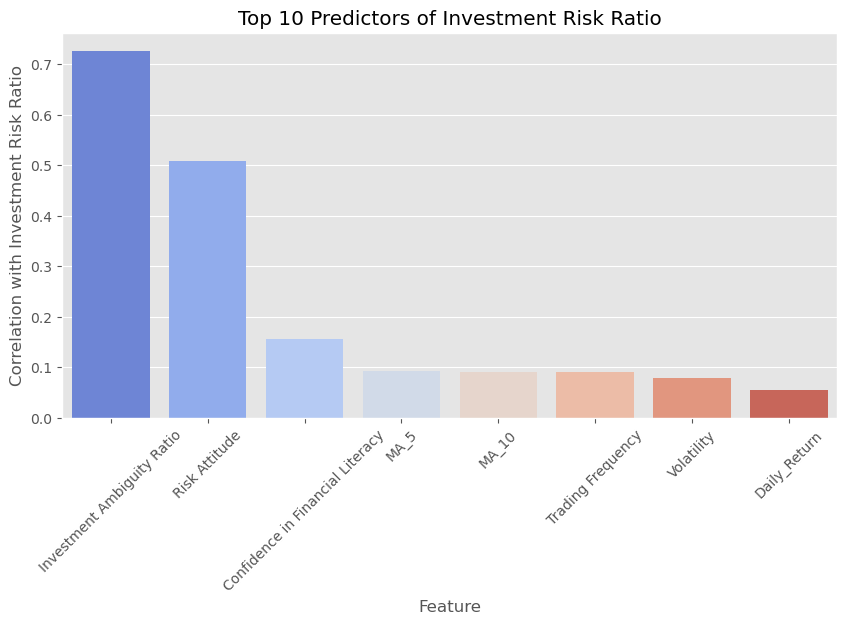

In [24]:
# Identify top predictors of investment risk-taking behavior
target_column = "Investment Risk Ratio"  # Change to "Investment Ambiguity Ratio" if needed

top_features = corr_matrix[target_column].abs().sort_values(ascending=False)[1:11]

print(f"Top 10 Predictors of {target_column}:\n")
print(top_features)

# Visualize feature importance
plt.figure(figsize=(10, 5))
sns.barplot(x=top_features.index, y=top_features.values, palette="coolwarm")
plt.xticks(rotation=45)
plt.xlabel("Feature")
plt.ylabel(f"Correlation with {target_column}")
plt.title(f"Top 10 Predictors of {target_column}")
plt.show()


In [25]:
# Convert 'Investment Risk Ratio' to numeric, forcing errors to NaN if conversion fails
exp_data['Investment Risk Ratio'] = pd.to_numeric(exp_data['Investment Risk Ratio'], errors='coerce')

# Compute correlation after conversion
fear_correlation = exp_data['Fear Level'].corr(exp_data['Investment Risk Ratio'])

print(f"Correlation between Fear Level and Investment Risk Ratio: {fear_correlation:.4f}")

Correlation between Fear Level and Investment Risk Ratio: -0.0816


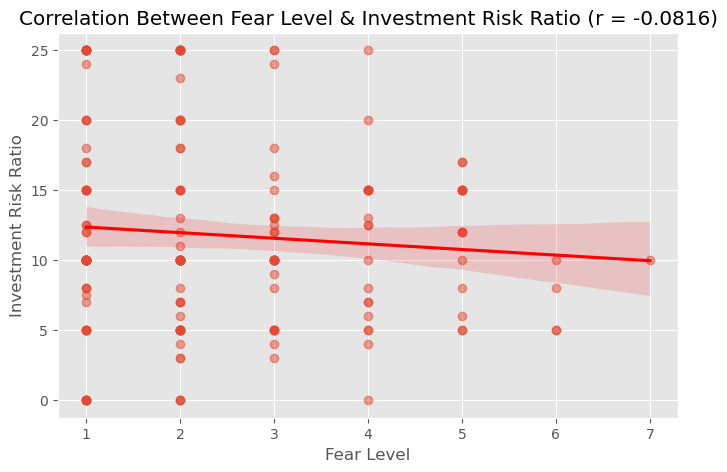

In [26]:
# Create scatter plot with regression line
plt.figure(figsize=(8, 5))
sns.regplot(x=exp_data['Fear Level'], y=exp_data['Investment Risk Ratio'], scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})

# Labels and title
plt.xlabel("Fear Level")
plt.ylabel("Investment Risk Ratio")
plt.title(f"Correlation Between Fear Level & Investment Risk Ratio (r = {fear_correlation:.4f})")

# Show plot
plt.show()

In [27]:
print("Available columns in exp_data:\n", exp_data.columns)

Available columns in exp_data:
 Index(['Interview Number', 'Serial Number', 'Reference', 'Survey Used',
       'Interview Mode', 'Seat Number', 'Trading Frequency', 'Delegation',
       'Trust in Advisor', 'Patience', 'Risk Attitude', 'Question 1',
       'Question 2', 'Question 3', 'Question 4', 'Question 5',
       'Investment Scenario', 'Good Mood Level', 'Fear Level',
       'Investment Ambiguity Ratio', 'Guessing Percentage',
       'Investment Risk Ratio', 'Optimism', 'Job Security',
       'Bullish Sentiment', 'Financial Literacy 1', 'Financial Literacy 2',
       'Financial Literacy 3', 'Financial Literacy 4',
       'Confidence in Financial Literacy', 'Age', 'Gender', 'Nationality',
       'Study Program', 'Income', 'Comments', 'Time Spent Page 1',
       'Time Spent Page 2', 'Time Spent Page 3', 'Time Spent Page 4',
       'Time Spent Page 5', 'Time Spent Page 6', 'Time Spent Page 7',
       'Time Spent Page 8', 'Time Spent Page 9', 'Time Spent Page 10',
       'Time Spent Pa

In [28]:
# Check data types in exp_data
print("Data Types in exp_data:\n", exp_data.dtypes)

# If merged_data exists, check its data types
if 'merged_data' in globals():
    print("\nData Types in merged_data:\n", merged_data.dtypes)
else:
    print("\nmerged_data is not defined in the current environment.")


Data Types in exp_data:
 Interview Number                 int64
Serial Number                  float64
Reference                      float64
Survey Used                     object
Interview Mode                  object
                                ...   
Weighted Missing Answers         int64
Penalty for Missing Answers    float64
Penalty for Fast Completion      int64
Total Penalty                  float64
Date                            object
Length: 63, dtype: object

Data Types in merged_data:
 Interview Number      int64
Serial Number       float64
Reference           float64
Survey Used          object
Interview Mode       object
                     ...   
Stock Splits        float64
Daily_Return        float64
Volatility          float64
MA_5                float64
MA_10               float64
Length: 74, dtype: object


In [29]:
df_logistic = merged_data[['Investment Risk Ratio']]
print(df_logistic.head())
print(df_logistic.shape)


   Investment Risk Ratio
0                     10
19                    10
21                     5
22                     5
23                    10
(201, 1)


In [30]:
print(merged_data.columns[merged_data.columns.duplicated()])

Index([], dtype='object')


In [31]:
df_logistic['Investment Risk Ratio'] = pd.to_numeric(df_logistic['Investment Risk Ratio'], errors='coerce')


C:\Users\amrit\AppData\Local\Temp\ipykernel_5340\3982530554.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_logistic['Investment Risk Ratio'] = pd.to_numeric(df_logistic['Investment Risk Ratio'], errors='coerce')


In [32]:
# Drop duplicate "Investment Risk Ratio" column (keep the first occurrence)
df_logistic = df_logistic.loc[:, ~df_logistic.columns.duplicated()]

# Verify columns after removing the duplicate
print("Fixed df_logistic Columns:\n", df_logistic.columns)

# Convert target variable to binary: High Risk (1) vs. Low Risk (0)
threshold = df_logistic['Investment Risk Ratio'].median()
df_logistic['Investment Risk Binary'] = (df_logistic['Investment Risk Ratio'] > threshold).astype(int)

# Check if the issue is resolved
print(df_logistic[['Investment Risk Ratio', 'Investment Risk Binary']].head())

Fixed df_logistic Columns:
 Index(['Investment Risk Ratio'], dtype='object')
    Investment Risk Ratio  Investment Risk Binary
0                    10.0                       0
19                   10.0                       0
21                    5.0                       0
22                    5.0                       0
23                   10.0                       0


In [33]:
# Convert 'Investment Risk Ratio' to numeric, handling errors
merged_data['Investment Risk Ratio'] = pd.to_numeric(merged_data['Investment Risk Ratio'], errors='coerce')

# Define feature list (correlation features we verified)
correlation_features = [
    "Trading Frequency", "Risk Attitude", "Investment Ambiguity Ratio",
    "Investment Risk Ratio", "Confidence in Financial Literacy",
    "Daily_Return", "Volatility", "MA_5", "MA_10"
]

# Ensure selected columns exist in merged_data
available_features = [col for col in correlation_features if col in merged_data.columns]
print("Using these features for Logistic Regression:", available_features)

Using these features for Logistic Regression: ['Trading Frequency', 'Risk Attitude', 'Investment Ambiguity Ratio', 'Investment Risk Ratio', 'Confidence in Financial Literacy', 'Daily_Return', 'Volatility', 'MA_5', 'MA_10']


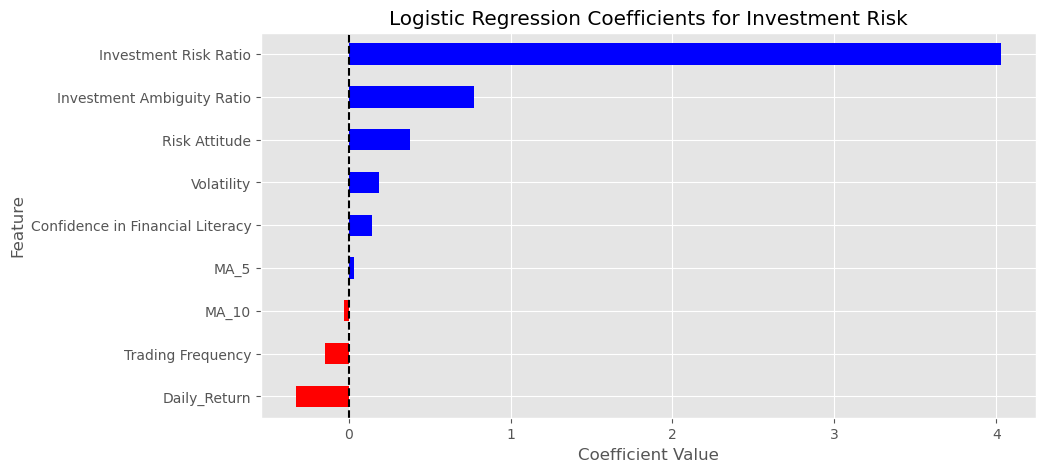

Logistic Regression Coefficients:
 Daily_Return                       -0.323210
Trading Frequency                  -0.148229
MA_10                              -0.030658
MA_5                                0.034872
Confidence in Financial Literacy    0.147209
Volatility                          0.185266
Risk Attitude                       0.380081
Investment Ambiguity Ratio          0.777378
Investment Risk Ratio               4.027758
dtype: float64


In [34]:
## LOGISTIC RFEGRESSION COEFFICIENTS

# Prepare data: Drop NaNs and select relevant features
df_logistic = merged_data[available_features + ['Investment Risk Ratio']].dropna()

# Remove duplicate columns (if any exist)
df_logistic = df_logistic.loc[:, ~df_logistic.columns.duplicated()]

# Convert target variable to binary: High Risk (1) vs. Low Risk (0)
threshold = df_logistic['Investment Risk Ratio'].median()
df_logistic['Investment Risk Binary'] = (df_logistic['Investment Risk Ratio'].values > threshold).astype(int)

# Define X (features) and y (target)
X = df_logistic[available_features]
y = df_logistic['Investment Risk Binary']

# Standardize features for better model performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Logistic Regression Model
log_reg = LogisticRegression()
log_reg.fit(X_scaled, y)

# Extract and sort coefficients
coefficients = pd.Series(log_reg.coef_[0], index=available_features).sort_values()

# Plot coefficients
plt.figure(figsize=(10, 5))
coefficients.plot(kind="barh", color=["red" if c < 0 else "blue" for c in coefficients])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Logistic Regression Coefficients for Investment Risk")
plt.axvline(x=0, color="black", linestyle="--")
plt.show()

# Print coefficients
print("Logistic Regression Coefficients:\n", coefficients)

Interpretation of Logistic Regression Coefficients:

Positive Coefficients (Increase Risk-Taking)
- Investment Risk Ratio (+4.03) → Strongest predictor of taking risks. A higher existing investment risk ratio strongly correlates with taking more risks.
- Investment Ambiguity Ratio (+0.78) → People who are comfortable with ambiguity tend to take more risks.
- Risk Attitude (+0.38) → Higher self-reported risk tolerance leads to more risk-taking.
- Volatility (+0.18) → People react to market volatility but not strongly.
- Confidence in Financial Literacy (+0.15) → Higher financial confidence slightly increases risk-taking.

Negative Coefficients (Reduce Risk-Taking)
- Daily Return (-0.32) → Higher daily returns may make investors more cautious, possibly due to profit-taking.
- Trading Frequency (-0.15) → More frequent trading slightly reduces risk-taking, suggesting that frequent traders are more cautious and calculated.
- MA_10 (-0.03) → Minor effect, but suggests that longer-term moving averages may encourage stability rather than risk-taking.

                            Feature  Coefficient
0                 Trading Frequency    -0.147912
1                     Risk Attitude     0.379927
2        Investment Ambiguity Ratio     0.777227
3             Investment Risk Ratio     4.027694
4  Confidence in Financial Literacy     0.147389
5                      Daily_Return    -0.322832
6                        Volatility     0.184425
7                              MA_5     0.035701
8                             MA_10    -0.031853

Intercept: -0.008173363299404195

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        84
           1       0.98      0.94      0.96        69

    accuracy                           0.97       153
   macro avg       0.97      0.97      0.97       153
weighted avg       0.97      0.97      0.97       153



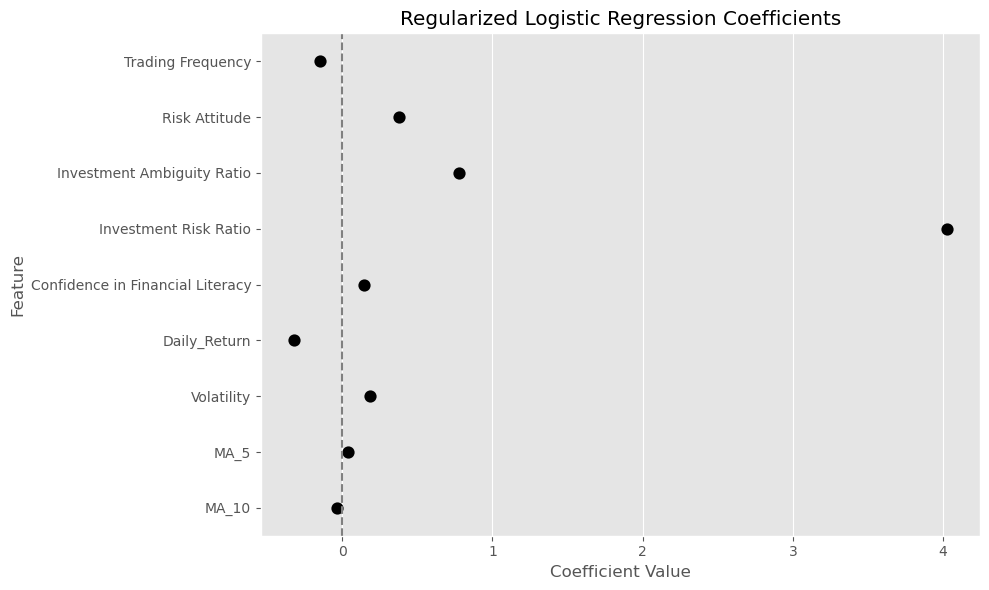

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np

# Drop the constant column for sklearn (it adds intercept internally)
X_final = pd.DataFrame(X_scaled, columns=available_features)  
y_aligned = y  # assuming y is already aligned with X

# Train regularized logistic regression
clf = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)
clf.fit(X_final, y_aligned)

# Print coefficients
coef_df = pd.DataFrame({
    "Feature": X_final.columns,
    "Coefficient": clf.coef_[0]
})
print(coef_df)

# Print intercept and performance
print("\nIntercept:", clf.intercept_[0])
print("\nClassification Report:")
print(classification_report(y_aligned, clf.predict(X_final)))

# Optional: Plot coefficients
plt.figure(figsize=(10, 6))
sns.pointplot(
    data=coef_df,
    x="Coefficient",
    y="Feature",
    color="black",
    capsize=0.2,
    err_kws={'linewidth': 1},
    linestyle='none'
)
plt.axvline(x=0, linestyle="--", color="gray")
plt.title("Regularized Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
""" 
When I am running this piece of code - I am getting this error:
"LinAlgError: Singular matrix"
Which chatgpt explained to me as:
"One or more of your input features is perfectly collinear with another (or a combination of others), 
causing the matrix inversion step in logistic regression to fail."

Here is the code:
"""

# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# import statsmodels.api as sm

# # 1. Sklearn: Regularized Logistic Regression
# X_final = pd.DataFrame(X_scaled, columns=available_features)
# y_aligned = y

# clf = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)
# clf.fit(X_final, y_aligned)

# coef_df = pd.DataFrame({
#     "Feature": X_final.columns,
#     "Coefficient": clf.coef_[0]
# })
# print(coef_df)

# print("\nIntercept:", clf.intercept_[0])
# print("\nClassification Report:")
# print(classification_report(y_aligned, clf.predict(X_final)))

# # Optional: Dot Plot (no error bars)
# plt.figure(figsize=(10, 6))
# sns.pointplot(
#     data=coef_df,
#     x="Coefficient",
#     y="Feature",
#     color="black",
#     capsize=0.2,
#     err_kws={'linewidth': 1},
#     linestyle='none'
# )
# plt.axvline(x=0, linestyle="--", color="gray")
# plt.title("Regularized Logistic Regression Coefficients")
# plt.xlabel("Coefficient Value")
# plt.ylabel("Feature")
# plt.tight_layout()
# plt.show()

# # 2. Statsmodels: Logistic Regression with Standard Errors
# X_with_const = sm.add_constant(X_scaled)
# model = sm.Logit(y_aligned, X_with_const).fit()

# summary_df = pd.DataFrame({
#     "Feature": X_with_const.columns,
#     "Coefficient": model.params,
#     "Std_Error": model.bse
# })

# # Error bar plot with standard errors
# plt.figure(figsize=(10, 6))
# plt.errorbar(
#     summary_df["Coefficient"],
#     summary_df["Feature"],
#     xerr=summary_df["Std_Error"],
#     fmt='o',
#     color='black',
#     capsize=4
# )
# plt.axvline(x=0, linestyle="--", color="gray")
# plt.title("Logistic Regression Coefficients with Standard Errors")
# plt.xlabel("Coefficient Estimate")
# plt.ylabel("Feature")
# plt.tight_layout()
# plt.show()

Using these features for Random Forest: ['Trading Frequency', 'Risk Attitude', 'Investment Ambiguity Ratio', 'Investment Risk Ratio', 'Confidence in Financial Literacy', 'Daily_Return', 'Volatility', 'MA_5', 'MA_10']
Fixed df_rf Columns:
 Index(['Trading Frequency', 'Risk Attitude', 'Investment Ambiguity Ratio',
       'Investment Risk Ratio', 'Confidence in Financial Literacy',
       'Daily_Return', 'Volatility', 'MA_5', 'MA_10'],
      dtype='object')
Shape of 'Investment Risk Ratio' column:
 (153, 1)
    Investment Risk Ratio  Investment Risk Binary
44                   18.0                       1
51                    5.0                       0
50                   20.0                       1
49                   15.0                       1
48                    5.0                       0


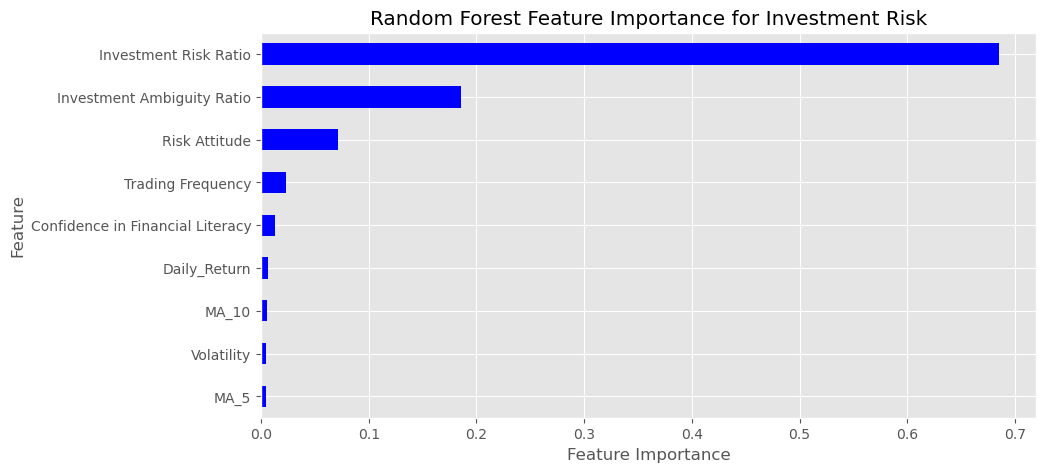

Random Forest Feature Importance:
 MA_5                                0.004568
Volatility                          0.004880
MA_10                               0.005571
Daily_Return                        0.006792
Confidence in Financial Literacy    0.013231
Trading Frequency                   0.022931
Risk Attitude                       0.071425
Investment Ambiguity Ratio          0.185413
Investment Risk Ratio               0.685190
dtype: float64


In [ ]:
## RANDOM FOREST

# Ensure selected columns exist in merged_data
available_features = [col for col in correlation_features if col in merged_data.columns]
print("Using these features for Random Forest:", available_features)

# Prepare data: Drop NaNs and select relevant features
df_rf = merged_data[available_features + ['Investment Risk Ratio']].dropna()

# Drop duplicate columns (if any exist)
df_rf = df_rf.loc[:, ~df_rf.columns.duplicated()]

# Verify columns after removing duplicates
print("Fixed df_rf Columns:\n", df_rf.columns)

# Ensure 'Investment Risk Ratio' is a single column
print("Shape of 'Investment Risk Ratio' column:\n", df_rf[['Investment Risk Ratio']].shape)

# Convert target variable to binary: High Risk (1) vs. Low Risk (0)
threshold = df_rf['Investment Risk Ratio'].median()
df_rf['Investment Risk Binary'] = (df_rf['Investment Risk Ratio'].values.flatten() > threshold).astype(int)

# Verify if binary target was created correctly
print(df_rf[['Investment Risk Ratio', 'Investment Risk Binary']].head())

# Define X (features) and y (target)
X = df_rf[available_features]
y = df_rf['Investment Risk Binary']

# Standardize features for better model performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_scaled, y)

# Extract feature importances
feature_importances = pd.Series(rf_model.feature_importances_, index=available_features).sort_values()

# Plot feature importances
plt.figure(figsize=(10, 5))
feature_importances.plot(kind="barh", color="blue")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance for Investment Risk")
plt.show()

# Print feature importances
print("Random Forest Feature Importance:\n", feature_importances)

Interpretation of Random Forest Feature Importance:

- Investment Risk Ratio (0.69) → Most important predictor of investment risk-taking behavior.
- Investment Ambiguity Ratio (0.18) → Strong influence, indicating that comfort with ambiguity plays a major role in risk-taking decisions.
- Risk Attitude (0.07) → Moderate impact, suggesting that self-reported risk preferences affect decisions but not as strongly as ambiguity tolerance.
- Trading Frequency (0.02) → Minor influence, meaning that how often a person trades does not heavily dictate risk-taking behavior.
- Confidence in Financial Literacy (0.01) → Very low impact, implying that self-confidence in financial knowledge does not strongly predict investment risk choices.
- Market Indicators (Daily Return, Volatility, MA_5, MA_10) all have near-zero importance → Market fluctuations do not strongly influence individual investment risk decisions.

Comparison with Logistic Regression:

- Both models agree that "Investment Risk Ratio" is the most dominant factor.
- Investment Ambiguity Ratio remains an important predictor in both models.
- Risk Attitude plays a smaller role than ambiguity tolerance in both models.
- Market-related features (volatility, moving averages, daily returns) were weak predictors in both models.
- Confidence in financial literacy was more important in Logistic Regression than in Random Forest but still had a small effect overall.

Considering the Small Dataset: Logistic Regression vs. Random Forest:

- The dataset is very small, with 201 samples and 74 features.
- Only 191 samples have DAX-related data.
- Limited data means models may not generalize well.

Which Model is More Reliable?
- Logistic Regression works well with small datasets and is less prone to overfitting.
- Random Forest requires more data to properly learn patterns.
- Logistic Regression provides interpretable coefficients, while Random Forest does not.
- Random Forest can capture non-linear relationships, but with this small dataset, it may overfit.
- Given the small dataset, Logistic Regression is the better baseline model.

Does It Even Matter Since Our Main Focus is Reddit K-Means?
- Since this is just a baseline comparison, the choice between the two models is not very critical.
- Both models highlight Investment Risk Ratio and Investment Ambiguity Ratio as key predictors.
- The primary analysis will be K-Means clustering on Reddit data, so the baseline model is only a reference point.